![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 03 | Hypotheses and Visualisation

*Project 1 — SQL: From Data to Insight*

**Team:** Zoé Doucet
**Dataset:** The Global Impacts Dataset of Invasive Alien Species (GIDIAS)

---
## 0. Setup

In [3]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. The question

Invasive species are non-native organisms, such as plants, animals, fungi, and even microorganisms, that spread in a new environment. They can damage ecosystems by disrupting their functions and affect economies by impacting people’s activities. It is therefore important to investigate invasive species, including their numbers, distribution, and impacts.

The three following question could bring more insight on invasive species spreading and their impact in different parts of the world.

1. When did invasive species introductions peak, and was there a period of rapid increase?
- The number of invasive species is increasing rapidly, with the rate of increase becoming more pronounced from the 2000s onwards.
- The introduction of invasive species reached its highest level between 2010 and 2019.


2. Which region and countries are the most affected by invasive species?
- Africa is the region most affected by invasive species.
- The five countries most affected by invasive species are Spain, Kenya, Brazil, the United States, and Indonesia.


3. Which invasive species have the greater impact?
- Species from the kingdom Plantae have the greatest impact on the environment.
- Species from the kingdom Animalia have the greatest impact on human activities.
- Across all countries, the three animal taxa with the greatest impact on the environment and human activities are Formicidae, Muridae, and Salmonidae.
- Across all countries, the three plant taxa with the greatest impact on the environment and human activities are Solanaceae, Araceae, and Fabaceae.
- The ten species with the greatest impact on the environment are Sirex noctilio, Xanthogaleruca luteola, Ceratopteris thalictroides, Halotydeus destructor, Sminthurus viridis, Brevicoryne brassicae, Lipaphis erysimi, Myzus persicae, Aphis craccivora, and Bombus terrestris.
- The ten species with the greatest impact on human activities are Gambusia affinis, Apiosoma piscicola, Schyzocotyle acheilognathi, Lernaea cyprinacea, Ichthyophthirius multifiliis, Chilodonella piscicola, Chilodonella hexasticha, Argulus japonicus, Cyprinus carpio, and Coptodon rendalli.


---
## 2. The data



The data used in this anlysis comes from the Global Impacts Dataset of Invasive Alien Species (GIDIAS), which has first been published on the 21. of Mai 2025 by Springer Natur and authored by S. Bacher et al.  (https://doi.org/10.6084/m9.figshare.27908838).
The data was downloaded on the 25th of September 2026.

Each row represents one record of a species being invasive in a particular location and region. The location can be a country, a list of countries, or part of a country, such as an island. Each record also includes information about the impact the species has in that location. A species can appear several times in the dataset because it can have impacts of different magnitudes in different locations or regions.

The dataset was split into three tables:
- **Impact**: The impact table contains each recorded impact, represented by the primary key `unique_id`. Each species can appear in several rows because it can have impacts in different locations and with different magnitudes. The species are identified by the foreign key `species_id`, while the location is identified by the foreign key `location_id`.

- **Species**: The species table contains information about each species, such as its name, genus, phylum, and kingdom. Each species is represented only once and is uniquely identified by `species_id`, which is the primary key.

- **Location**: The location table contains information about the locations where invasive species have an impact. The `location_id`, which is the primary key, uniquely identifies each location based on its different location parameters, such as country and region.

![Invasive Species ERD](../images/ERD_invasiv_species_1.png)

---
## 3. Analysis

In [4]:
import sqlite3
import pandas as pd

# point this at wherever you saved the database
DB_PATH = "../project_inv_sp.db"

con = sqlite3.connect(DB_PATH)
print("Connection open")

Connection open


In [5]:
cursor = con.cursor()

In [6]:
with open("../sql/queries.sql", "r") as file:
    queries = file.read().split("--QUERY")

### 3.1 When did invasive species introductions peak, and was there a period of rapid increase?

In [7]:
query = queries[1]
q1h1 = pd.read_sql(query, con)
q1h1

,year,species recorded
0,1600,1
1,1800,1
2,1863,8
3,1868,1
4,1882,1
...,...,...
100,2017,314
101,2018,308
102,2019,438
103,2020,241


In [8]:
query = queries[2]
q1h2 = pd.read_sql(query, con)
q1h2

,decade,species recorded
0,2010,1940


### 3.2 Which region and countries are the most affected by invasive species?

In [9]:
query = queries[3]
q2h1 = pd.read_sql(query, con)
q2h1

,region,species recorded
0,Europe_and_Central_Asia,1675
1,Americas,1335
2,Asia-Pacific,1066
3,Africa,342
4,Antarctica,3


In [10]:
query = queries[4]
q2h2_1 = pd.read_sql(query, con)
q2h2_1

,country,species recorded
0,USA,761
1,Japan,324
2,Ecuador,275
3,South Africa,190
4,Spain,185
...,...,...
406,Antigua and Barbuda,1
407,Antarctica,1
408,American Samoa,1
409,Albania; France; Austria; United Kingdom; Swit...,1


In [11]:
query = queries[5]
q2h2_2 = pd.read_sql(query, con)
q2h2_2

,country,species recorded
0,USA,786
1,Japan,324
2,Ecuador,285
3,Spain,210
4,South Africa,194


### 3.3 Which invasive species has the greater impact?

#### 3.3.1 Which invasive species kingdom has the greater impact on nature and human activities? 

In [12]:
query = queries[6]
q3h1 = pd.read_sql(query, con)
q3h1

,kingdom,magnitude 3,magnitude 2,magnitude 1,magnitude 0
0,Animalia,171,390,525,221
1,Plantae,51,425,451,210
2,Fungi,5,19,8,7
3,Chromista,2,13,9,3
4,Viruses,1,3,5,0
5,Protozoa,1,2,2,0
6,Bacteria,0,2,1,0


In [13]:
query = queries[7]
q3h2 = pd.read_sql(query, con)
q3h2

,kingdom,magnitude 3,magnitude 2,magnitude 1,magnitude 0,positive impact
0,Animalia,19,108,224,66,1
1,Plantae,18,33,81,17,2
2,Viruses,2,2,3,0,0
3,Fungi,1,6,5,0,0
4,Bacteria,1,1,0,0,0
5,Chromista,0,1,2,1,0
6,incertae sedis,0,1,0,0,0


#### 3.3.2 Which are the three taxonomic families from the Animalia and Plantea kingdom that have the greatest impact on the environment and human activities in the five most affected countries? 

In [14]:
# most impactfull families from the Animalia kingdom on the environment
query = queries[8]
q3h3_1 = pd.read_sql(query, con)
q3h3_1

,country,family,magnitude 3
0,Ecuador,Formicidae,8
1,Ecuador,Muridae,2
2,Ecuador,Bovidae,2
3,Ecuador,Suidae,1
4,Ecuador,Muscidae,1
...,...,...,...
59,USA,Buprestidae,1
60,USA,Bopyridae,1
61,USA,Batillariidae,1
62,USA,Anatidae,1


In [15]:
# most impactfull families from the Animalia kingdom on human activities
query = queries[9]
q3h3_2 = pd.read_sql(query, con)
q3h3_2

,country,family,magnitude 3
0,South Africa,Corvidae,1
1,USA,Formicidae,1
2,USA,Buprestidae,1


In [16]:
# most impactfull families from the Plantae kingdom on the environment
query = queries[10]
q3h4_1 = pd.read_sql(query, con)
q3h4_1

,country,family,magnitude 3
0,Ecuador,Solanaceae,1
1,Ecuador,Meliaceae,1
2,Japan,Pontederiaceae,1
3,Japan,Moraceae,1
4,Japan,Hydrocharitaceae,1
5,South Africa,Salviniaceae,2
6,South Africa,Pontederiaceae,1
7,South Africa,Pinaceae,1
8,South Africa,Myrtaceae,1
9,South Africa,Fabaceae,1


In [17]:
# most impactfull families from the Plantae kingdom on human activities
query = queries[11]
q3h4_2 = pd.read_sql(query, con)
q3h4_2

,country,family,magnitude 3
0,South Africa,Salviniaceae,1


#### 3.3.3  Which are the 10 species that have the greatest impact on nature and human activities?

In [18]:
query = queries[12]
q3h5_1 = pd.read_sql(query, con)
q3h5_1

,species,magnitude 3,magnitude 2,magnitude 1,magnitude 0
0,Felis catus,108,34,13,0
1,Rattus rattus,74,35,51,0
2,Vulpes vulpes,69,17,3,0
3,Linepithema humile,50,26,43,0
4,Rattus exulans,41,28,13,0
5,Pterois volitans,39,69,15,0
6,Anoplolepis gracilipes,29,21,45,0
7,Solenopsis invicta,28,62,76,0
8,Capra hircus,27,32,15,0
9,Caulerpa taxifolia,21,29,8,0


In [19]:
query = queries[13]
q3h5_2 = pd.read_sql(query, con)
q3h5_2

,species,magnitude 3,magnitude 2,magnitude 1,magnitude 0
0,Eichhornia crassipes,21,14,19,0
1,Corvus splendens,6,3,5,0
2,Agrilus planipennis,3,14,12,0
3,Rhinella marina,3,6,15,0
4,Dengue virus,3,0,25,0
5,Wasmannia auropunctata,2,7,15,0
6,Salvinia molesta,2,2,10,0
7,Mikania micrantha,2,1,1,0
8,Solenopsis invicta,1,8,60,0
9,Vespa velutina nigrithorax,1,3,1,0


---
## 4. Visualisation

#### 4.1 When did invasive species introductions peak, and was there a period of rapid increase?

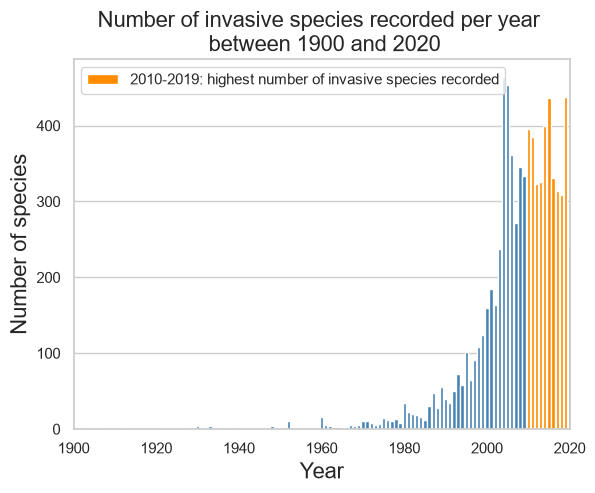

In [20]:
colors = ["darkorange" if 2010 <= year <= 2019 else "steelblue"
    for year in q1h1["year"]]

plt.bar(q1h1["year"], q1h1["species recorded"], 
    color=colors,
    alpha=1)
plt.xlabel("Year", fontsize=16)
plt.ylabel("Number of species", fontsize=16)
plt.title("Number of invasive species recorded per year \n between 1900 and 2020", fontsize=16)
plt.grid(axis="x")
plt.xlim(1900, 2020)
plt.gca().set_axisbelow(True)
plt.legend(handles=[Patch(facecolor="darkorange", label="2010-2019: highest number of invasive species recorded")])
plt.show()

#### 4.2 Which region and countries are the most affected by invasive species?

C:\Users\zoed\AppData\Local\Temp\ipykernel_44888\2072952349.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  plt_q2h1.set_xticklabels(labels)


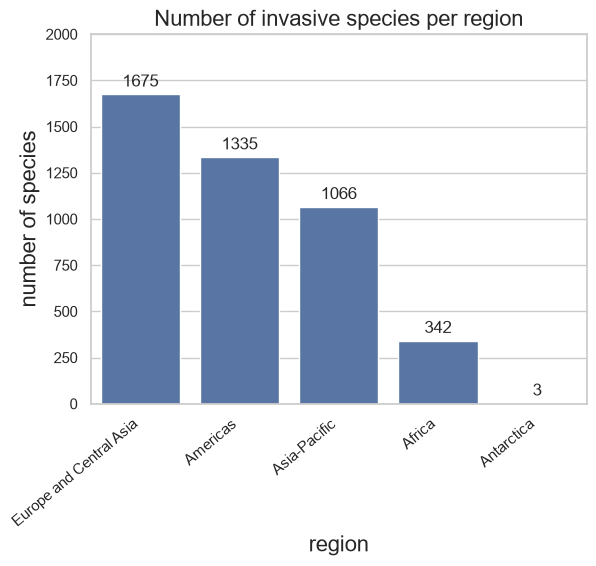

In [21]:

plt_q2h1 = sns.barplot(q2h1, x="region", y="species recorded")
plt_q2h1.set_ylim(0, 2000)
plt_q2h1.set_title("Number of invasive species per region", fontsize=16)
plt_q2h1.set_ylabel("number of species", fontsize=16)
plt_q2h1.set_xlabel("region", fontsize=16)
labels = [label.get_text().replace("_", " ") for label in plt_q2h1.get_xticklabels()]
plt_q2h1.set_xticklabels(labels)
plt.xticks(rotation=40, ha="right")

for container in plt_q2h1.containers:
    plt_q2h1.bar_label(container, fmt="%.0f", padding=3)

plt.show()


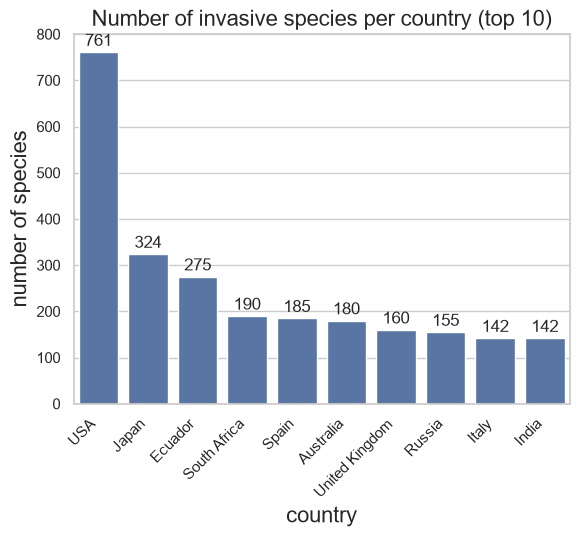

In [22]:
top_10 = q2h2_1.head(10)
plt_q2h2 = sns.barplot(top_10, x="country", y="species recorded")
plt_q2h2.set_ylim(0,  800)
plt_q2h2.set_title("Number of invasive species per country (top 10)",fontsize=16)
plt_q2h2.set_ylabel("number of species", fontsize=16)
plt_q2h2.set_xlabel("country", fontsize=16)
plt.xticks(rotation=45, ha="right")

for container in plt_q2h2.containers:
    plt_q2h2.bar_label(container, fmt="%.0f", padding=2)

plt.show()


#### 4.3 Which invasive species have the greater impact?

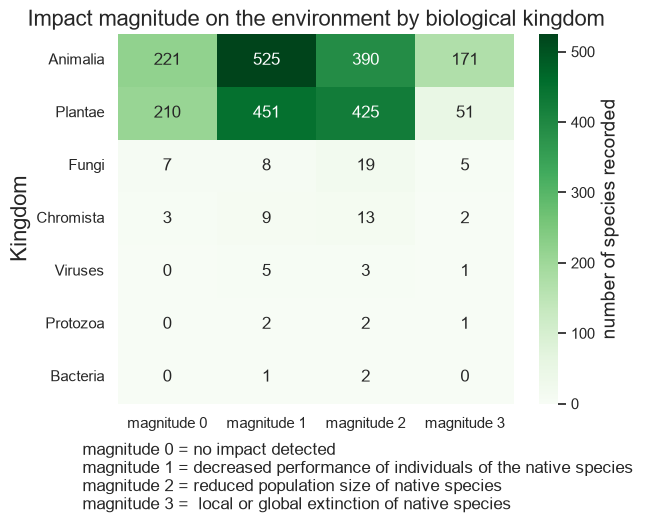

In [23]:
index_q3h1 = q3h1.set_index("kingdom")[["magnitude 0", "magnitude 1", "magnitude 2", "magnitude 3"]]
ax=sns.heatmap(
    index_q3h1,
    annot=True,
    fmt="d",
    cmap="Greens"
)
cbar = ax.collections[0].colorbar
cbar.set_label("number of species recorded", fontsize=14)
plt.xlabel("", fontsize=16)
plt.ylabel("Kingdom",fontsize=16)
plt.title("Impact magnitude on the environment by biological kingdom",fontsize=16)
plt.figtext(0.07, -0.11,
    "magnitude 0 = no impact detected \n" \
    "magnitude 1 = decreased performance of individuals of the native species \n" \
    "magnitude 2 = reduced population size of native species  \n" \
    "magnitude 3 =  local or global extinction of native species",
    ha="left",
    fontsize=12)
plt.show()

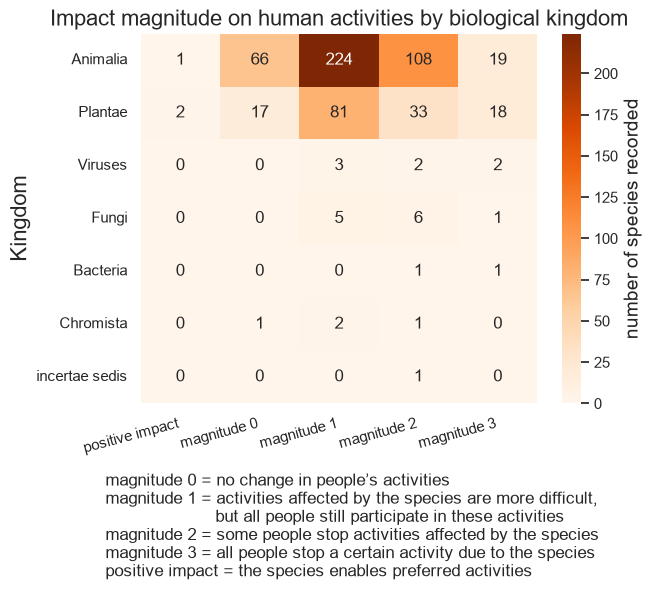

In [24]:
index_q3h2 = q3h2.set_index("kingdom")[["positive impact","magnitude 0", "magnitude 1", "magnitude 2", "magnitude 3"]]
ax=sns.heatmap(
    index_q3h2,
    annot=True,
    fmt="d",
    cmap="Oranges")

cbar = ax.collections[0].colorbar
cbar.set_label("number of species recorded", fontsize=14)
plt.xlabel("")
plt.ylabel("Kingdom", fontsize=16)
plt.title("Impact magnitude on human activities by biological kingdom", fontsize=16)
plt.xticks(rotation=15, ha="right")
plt.figtext(0.07, -0.25,
    "magnitude 0 = no change in people’s activities \n" \
    "magnitude 1 = activities affected by the species are more difficult, \n" 
    "                      but all people still participate in these activities \n" \
    "magnitude 2 = some people stop activities affected by the species\n" \
    "magnitude 3 = all people stop a certain activity due to the species \n" \
    "positive impact = the species enables preferred activities",
    ha="left",
    fontsize=12)
plt.show()

In [25]:
# top three taxa with the greatets impact on nature form the Animalia kingdom in the top five most affected countries
top3_q3h3_1 = (q3h3_1
    .sort_values(["country", "magnitude 3"], ascending=[True, False])
    .groupby("country")
    .head(3))
top3_q3h3_1

,country,family,magnitude 3
0,Ecuador,Formicidae,8
1,Ecuador,Muridae,2
2,Ecuador,Bovidae,2
9,Japan,Formicidae,2
10,Japan,Suidae,1
11,Japan,Serpulidae,1
19,South Africa,Salmonidae,2
20,South Africa,Mytilidae,2
21,South Africa,Centrarchidae,2
26,Spain,Formicidae,2


In [26]:
# top three taxa with the greatets impact on nature form the Plantae kingdom in the top five most affected countries
top3_q3h4_1 = (q3h4_1
    .sort_values(["country", "magnitude 3"], ascending=[True, False])
    .groupby("country")
    .head(3))
print(top3_q3h3_1)

         country         family  magnitude 3
0        Ecuador     Formicidae            8
1        Ecuador        Muridae            2
2        Ecuador        Bovidae            2
9          Japan     Formicidae            2
10         Japan         Suidae            1
11         Japan     Serpulidae            1
19  South Africa     Salmonidae            2
20  South Africa      Mytilidae            2
21  South Africa  Centrarchidae            2
26         Spain     Formicidae            2
27         Spain     Colubridae            2
28         Spain        Muridae            1
32           USA     Formicidae           10
33           USA     Spiraxidae            2
34           USA   Scorpaenidae            2


In [27]:
# top three taxa with the greatets impact on human activities form the Animalia kingdom in the top five most affected countries
top3_q3h3_1 = (q3h3_2
    .sort_values(["country", "magnitude 3"], ascending=[True, False])
    .groupby("country")
    .head(3))
print(top3_q3h3_1)

        country       family  magnitude 3
0  South Africa     Corvidae            1
1           USA   Formicidae            1
2           USA  Buprestidae            1


In [28]:
# top three taxa with the greatets impact on human activities form the Plantae kingdom in the top five most affected countries
top3_q3h3_1 = (q3h4_2
    .sort_values(["country", "magnitude 3"], ascending=[True, False])
    .groupby("country")
    .head(3))
print(top3_q3h3_1)

        country        family  magnitude 3
0  South Africa  Salviniaceae            1


C:\Users\zoed\AppData\Local\Temp\ipykernel_44888\1460541382.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax_q3h5_1.set_yticklabels(labels_q3h5_1)


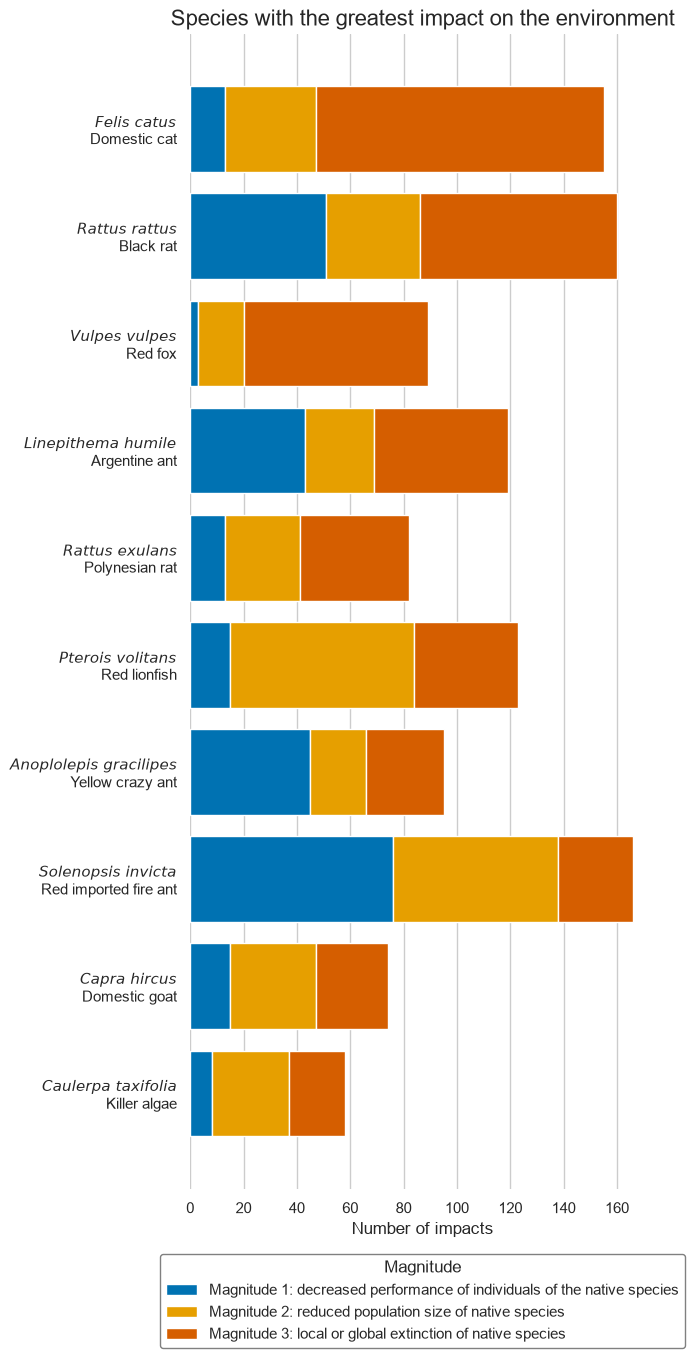

In [29]:
latin_names_q3h5_1 = ["Felis catus","Rattus rattus","Vulpes vulpes","Linepithema humile",
                      "Rattus exulans","Pterois volitans","Anoplolepis gracilipes","Solenopsis invicta",
                      "Capra hircus","Caulerpa taxifolia"]
common_names_q3h5_1 = ["Domestic cat","Black rat","Red fox","Argentine ant","Polynesian rat",
                       "Red lionfish","Yellow crazy ant","Red imported fire ant","Domestic goat","Killer algae"]

labels_q3h5_1 = [
    rf"$\it{{{latin.replace(' ', '\ ')}}}$" + f"\n{name}"
    for latin, name in zip(latin_names_q3h5_1, common_names_q3h5_1)]

sns.set_theme(style="whitegrid")

# Initialize the matplotlib figure
f, ax_q3h5_1 = plt.subplots(figsize=(6, 15))

ax_q3h5_1.barh(
    q3h5_1["species"],
    q3h5_1["magnitude 1"],
    label = "Magnitude 1: decreased performance of individuals of the native species",
    color = "#0072B2")
ax_q3h5_1.barh(
    q3h5_1["species"],
    q3h5_1["magnitude 2"],
    left=q3h5_1["magnitude 1"],
    label = "Magnitude 2: reduced population size of native species",
    color = "#E69F00")
ax_q3h5_1.barh(
    q3h5_1["species"],
    q3h5_1["magnitude 3"],
    left=q3h5_1["magnitude 1"] + q3h5_1["magnitude 2"],
    label = "Magnitude 3: local or global extinction of native species",
    color = "#D55E00")

ax_q3h5_1.set_xlabel("Number of impacts")
ax_q3h5_1.set_ylabel("")
ax_q3h5_1.set_yticklabels(labels_q3h5_1)
ax_q3h5_1.set_title("Species with the greatest impact on the environment", fontsize=16)

ax_q3h5_1.legend(
    title="Magnitude",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=1,
    frameon=True,
    fancybox=True,
    framealpha=1,
    edgecolor="grey",
    facecolor="white")

ax_q3h5_1.invert_yaxis()
ax_q3h5_1.grid(axis="y", visible=False)

sns.despine(left=True, bottom=True)

plt.show()


C:\Users\zoed\AppData\Local\Temp\ipykernel_44888\118815632.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax_q3h5_2.set_yticklabels(labels_q3h5_2)


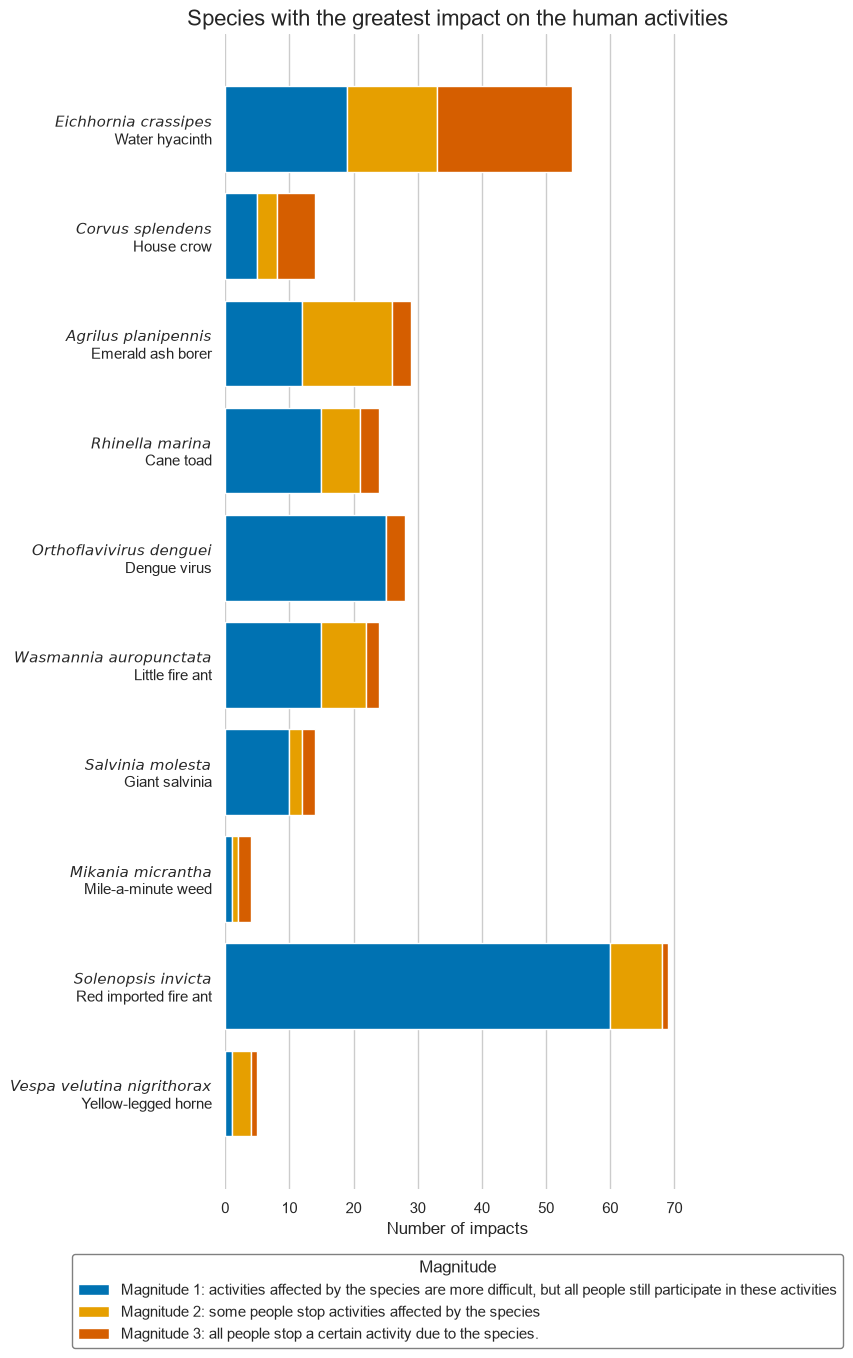

In [30]:
latin_names_q3h5_2 = ["Eichhornia crassipes","Corvus splendens","Agrilus planipennis",
                      "Rhinella marina", "Orthoflavivirus denguei","Wasmannia auropunctata",
                      "Salvinia molesta","Mikania micrantha","Solenopsis invicta","Vespa velutina nigrithorax"]
common_names_q3h5_2 = ["Water hyacinth","House crow","Emerald ash borer","Cane toad", "Dengue virus",
                       "Little fire ant","Giant salvinia","Mile-a-minute weed","Red imported fire ant","Yellow-legged horne"]

labels_q3h5_2 = [
    rf"$\it{{{latin.replace(' ', '\ ')}}}$" + f"\n{name}"
    for latin, name in zip(latin_names_q3h5_2, common_names_q3h5_2)]

sns.set_theme(style="whitegrid")

f, ax_q3h5_2 = plt.subplots(figsize=(6, 15))

ax_q3h5_2.barh(
    q3h5_2["species"],
    q3h5_2["magnitude 1"],
    label = "Magnitude 1: activities affected by the species are more difficult, but all people still participate in these activities",
    color = "#0072B2")
ax_q3h5_2.barh(
    q3h5_2["species"],
    q3h5_2["magnitude 2"],
    left=q3h5_2["magnitude 1"],
    label = "Magnitude 2: some people stop activities affected by the species",
    color = "#E69F00")
ax_q3h5_2.barh(
    q3h5_2["species"],
    q3h5_2["magnitude 3"],
    left=q3h5_2["magnitude 1"] + q3h5_2["magnitude 2"],
    label = "Magnitude 3: all people stop a certain activity due to the species.",
    color = "#D55E00")

ax_q3h5_2.set_xlabel("Number of impacts")
ax_q3h5_2.set_ylabel("")
ax_q3h5_2.set_yticklabels(labels_q3h5_2)
ax_q3h5_2.set_title("Species with the greatest impact on the human activities", fontsize=16)

ax_q3h5_2.legend(
    title="Magnitude",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=1,
    frameon=True,
    fancybox=True,
    framealpha=1,
    edgecolor="grey",
    facecolor="white")
ax_q3h5_2.invert_yaxis()
ax_q3h5_2.grid(axis="y", visible=False)

sns.despine(left=True, bottom=True)

plt.show()


---
## 5. Conclusions

1. When did invasive species introductions peak, and was there a period of rapid increase?

The number of alien invasive species has been increasing since 1600, which is the first record in the dataset. The rate of the increase has become more pronounced since 1990s. The decade with the most recorded invasive alien species has been 2010 to 2019. A peak is not yet visible as the number of alien species seems to still be increasing.
The hypothesis were partially right.

2. Which region and countries are the most affected by invasive species?

The region most affected by invasive alien species is Europe and Central Asia. Therefore, the hypothesis was not corect. Africa is the second-least affected region, with 342 invasive species recorded.

Nevertheless, South Africa ranks fourth among the countries with the highest number of invasive species. The United States has the highest number, followed by Japan, Ecuador, South Africa, and Spain. Therefore, the hypothesis was partially correct.

3. Which invasive species have the greater impact?

First, taking a look at the impact of invasive species on the environment and human activities, grouped by kingdom, the results show that species from the Animalia kingdom have the greatest impact on both the environment and human activities. The hypothesis was therefore only partially correct.

In the five most affected countries, the taxonomical families from the Animalia kingdom affecting the environment the most are, for Ecuador, Formicidae, Muridae, and Bovidae; for Japan, Formicidae, Suidae, and Serpulidae; for South Africa, Salmonidae, Mytilidae, and Centrarchidae; for Spain, Formicidae, Colubridae, and Muridae; and for the USA, Formicidae, Spiraxidae, and Scorpaenidae.

Taxonomical families from the Animalia kingdom affecting human activities the most were only reported in the USA and South Africa. For South Africa, it is the Corvidae family, while for the USA, it is one species from the Formicidae family and one from the Buprestidae family.

Now, taking a look at the most impactful families from the Plantae kingdom in the five most affected countries, the most impactful families for Ecuador are Solanaceae and Meliaceae; for Japan, Pontederiaceae, Moraceae, and Hydrocharitaceae; for South Africa, Salviniaceae, Pontederiaceae, and Pinaceae; for Spain, Rhodomelaceae and Poaceae; and for the USA, Poaceae, Hydrocharitaceae, and Typhaceae.

Only the USA and South Africa reported families from the Plantae kingdom impacting human activities. For South Africa, it is one species from the Corvidae family, while for the USA, it is one species from the Formicidae family and one from the Buprestidae family.
The results show that the hypotheses cannot be supported.

Lastly, the impact magnitudes one to three were counted and compared across all species. The ten species with the highest impact on the environment are: Felis catus, Rattus rattus, Vulpes vulpes, Linepithema humile, Rattus exulans, Pterois volitans, Anoplolepis gracilipes, Solenopsis invicta, Capra hircus, and Caulerpa taxifolia.

The ten species with the highest impact on human activities are: Eichhornia crassipes, Corvus splendens, Agrilus planipennis, Rhinella marina, Dengue virus, Wasmannia auropunctata, Salvinia molesta, Mikania micrantha, Solenopsis invicta, and Vespa velutina nigrithorax.


---
## 6. Limitations and next steps

The analysis gives us an overview of the evolution of the number of invasive species but does not show how the introduction of these species took place. Knowledge about the introduction of invasive species is key to preventing them from spreading.

Furthermore, it has to be acknowledged that the analysis of the number of invasive species per country is not complete. As some locations contain lists of countries, not all countries could be taken into consideration during the analysis. In the same way, some locations are islands that are part of countries and therefore might result in a country being counted twice for the same species. In hindsight, this dataset might have been too complex for such a short project. The data cleaning should have been more thorough.

With a cleaner dataset, it would be interesting to compare islands to determine whether they are more at risk from invasive alien species and whether they are more affected by certain species or groups of species.

An additional interesting analysis would have been to examine the countries most affected by the most invasive species. Creating a map with a colour gradient to illustrate how affected a country is by a certain species or family of species could provide interesting insights into the distribution of invasive alien species.